In [4]:
import xarray as xr
import numpy as np
import scipy
from matplotlib import pyplot as plt
from depsi.atmosphere import estimate_non_linear_deformation

## Load input and output from matlab files

In [2]:
data_input = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_filtering_input.mat")
stm = xr.Dataset(
    {
        "psc_phase": (["space", "time"], data_input['psc_phase_res']),
        "years": (["time"], data_input['Btemp'].squeeze()),
    },
).chunk({"space": 10, "time": -1})

In [3]:
data_output = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_filtering_output.mat")
non_linear = xr.Dataset(
    {
        "non_linear_matlab": (["space", "time"], data_output['non_linear']),
        "years": (["time"], data_input['Btemp'].squeeze()),
    },
).chunk({"space": 10, "time": -1})

## Inspect other input arguments

In [4]:
print(data_input['ts_atmo_filter'], data_input['ts_atmo_filter_length'])

['gaussian'] [[1]]


## Calculate "non_linear" using Python for comparison

In [5]:
non_linear["non_linear_python"] = estimate_non_linear_deformation(
        psc_phase=stm["psc_phase"],
        baseline_years=stm["years"],
        filter_length=30,
        method='gaussian',
    )

## Plot both

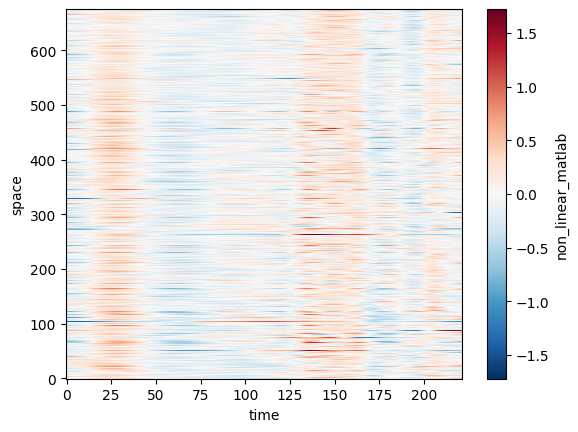

In [6]:
non_linear["non_linear_matlab"].plot(x="time", y="space")

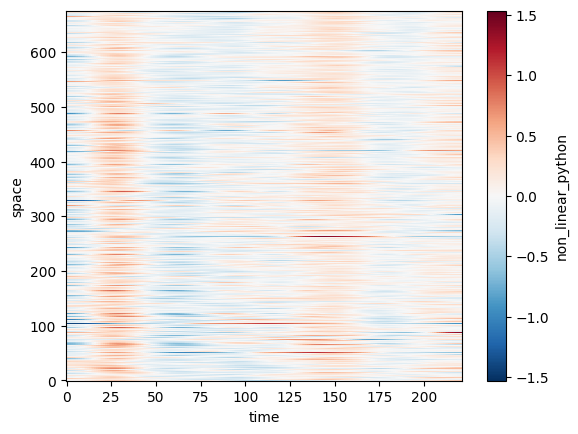

In [7]:
non_linear["non_linear_python"].plot(x="time", y="space")

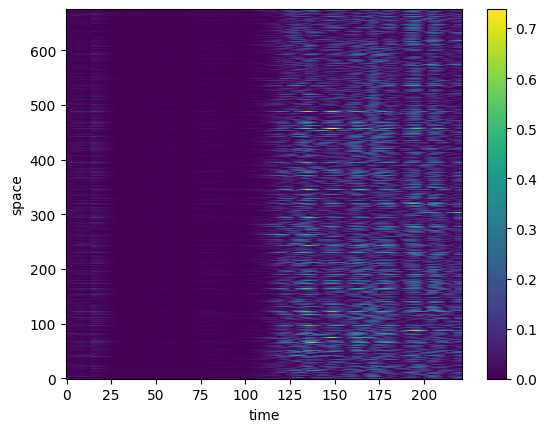

In [8]:
# absolute difference bewteen matlab and python
ae = abs(non_linear["non_linear_python"] - non_linear["non_linear_matlab"])
ae.plot(x="time", y="space")

In [54]:
first_part = estimate_non_linear_deformation(
        psc_phase=stm["psc_phase"],
        baseline_years=stm["years"],
        filter_length=30,
        method='gaussian',
    )

In [55]:
second_part = estimate_non_linear_deformation(
        psc_phase=stm["psc_phase"],
        baseline_years=stm["years"],
        filter_length=15,
        method='gaussian',
    )

In [56]:
non_linear["non_linear_python"] = xr.concat(
    [first_part.isel(time=np.arange(0,118)),
     second_part.isel(time=np.arange(118,222)),
    ],
    dim="time"
)

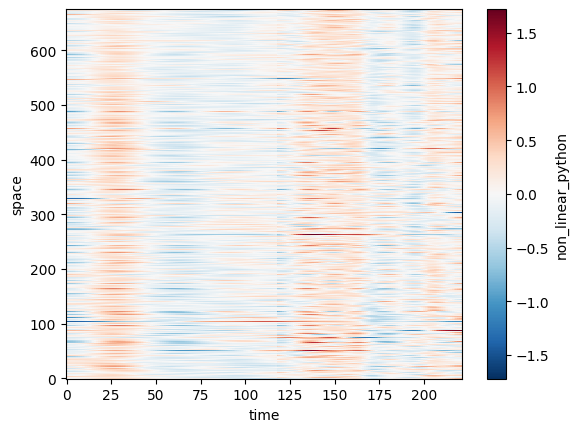

In [57]:
non_linear["non_linear_python"].plot(x="time", y="space")

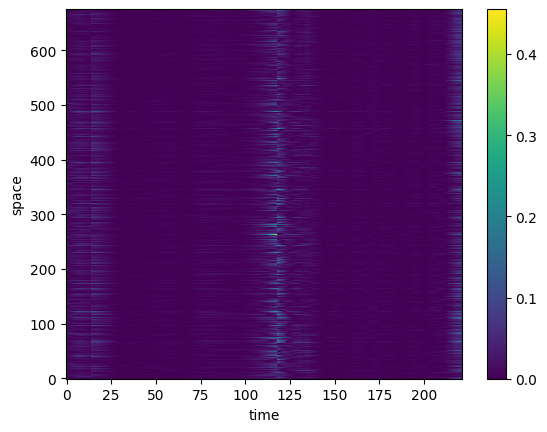

In [58]:
# absolute difference bewteen matlab and python
ae = abs(non_linear["non_linear_python"] - non_linear["non_linear_matlab"])
ae.plot(x="time", y="space")

## load kriging data

In [1]:
import xarray as xr
import numpy as np
import scipy
from matplotlib import pyplot as plt

In [2]:
data_input = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_atmo_kriging_input.mat")
ds = xr.Dataset(
    {
        "ps_atmosphere": (["space", "time"], data_input["atmo_estimates"])
    },
    coords={
        "x": ("space", data_input["psc_azx"].squeeze()),
        "y": ("space", data_input["psc_rx"].squeeze()),
    }
)

chunked_ds = xr.Dataset(
    {
        "ps_atmosphere": (["space", "time"], data_input["atmo_estimates"])
    },
    coords={
        "x": ("space", data_input["psc_azx"].squeeze()),
        "y": ("space", data_input["psc_rx"].squeeze()),
    }
).chunk({"space": -1, "time": 50})

### Explore some kriging info before actual interpolation

In [6]:
from depsi.atmosphere import krige_per_single_time

# select one time step
time_index = 0
ps_atmosphere = ds["ps_atmosphere"].isel(time=time_index)
atmos_variance = np.var(ps_atmosphere.values)

# parameters from matlab are default values in krige_per_single_time
# variogram_model='gaussian',
# variogram_parameters= {'sill': 0.8*atmos_variance, 'range':1000.0 , 'nugget': 0.2*atmos_variance}, 

kriging_obj = krige_per_single_time(ps_atmosphere)

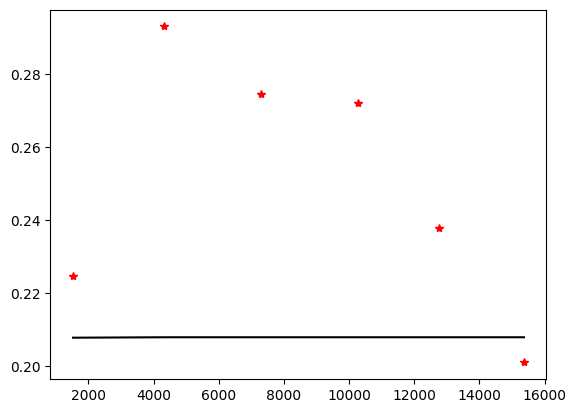

In [12]:
kriging_obj.display_variogram_model()

In [22]:
## create a gird
grid_size = 500
new_x = np.arange(ds["x"].min(), ds["x"].max() + grid_size, grid_size)
new_y = np.arange(ds["y"].min(), ds["y"].max() + grid_size, grid_size)
xr_grid = xr.Dataset(coords={'x': new_x, 'y': new_y})

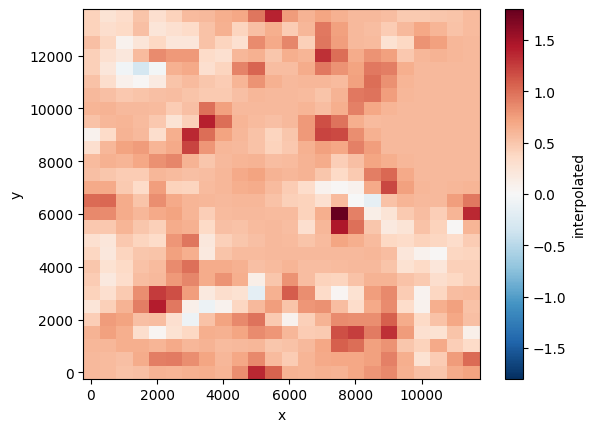

In [ ]:
interpolated, sigmasq = krige_per_single_time(ps_atmosphere, xr_grid)

xr_grid["interpolated"] = (('y', 'x'), interpolated)
xr_grid["interpolated"].plot()

### Now interpolation for all time steps

In [3]:
from depsi.atmosphere import krige_in_space

In [4]:
result = krige_in_space(ds["ps_atmosphere"].isel(time=[0, 1]), grid_size=500)

/home/sarah/GitHub/DePSI_group/depsi/atmosphere.py:220: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interpolated, sigmasq = xr.apply_ufunc(


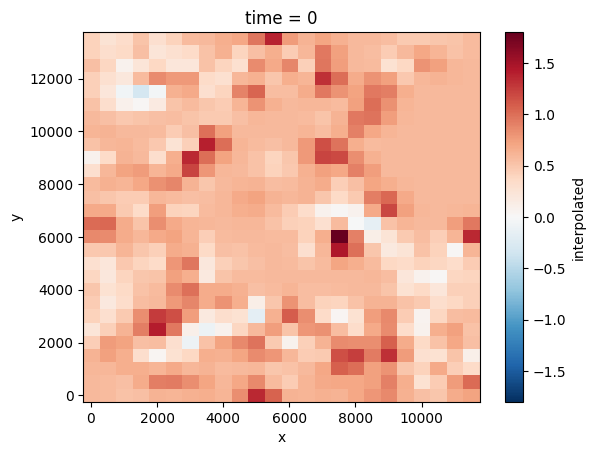

In [6]:
result["interpolated"].isel(time=0).plot()

In [7]:
result = krige_in_space(chunked_ds["ps_atmosphere"], grid_size=500)

/home/sarah/GitHub/DePSI_group/depsi/atmosphere.py:220: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interpolated, sigmasq = xr.apply_ufunc(


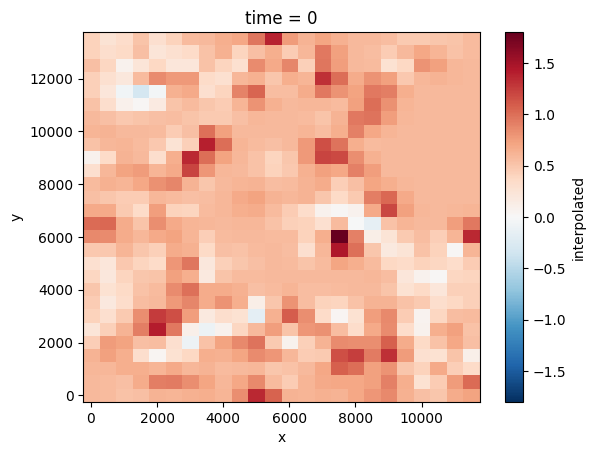

In [8]:
result["interpolated"].isel(time=0).plot()